In [1]:
import os, argparse, typing
os.chdir("../../")

import numpy as np
import pandas as pd
import scanpy as sc
import torch 

import PINN
from PINN import models as models
from PINN import reader 

In [2]:
import matplotlib.pyplot as plt
from PINN import pl
from importlib import reload

In [3]:
reload(reader)

<module 'PINN.reader' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/reader.py'>

In [ ]:
# load the anndata
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [ ]:
atlas = sc.read_h5ad("data/combined_filt.h5ad")
atlas

AnnData object with n_obs × n_vars = 130700 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', '

```python

# construct tompositive landscape
tom_pos = atlas[atlas.obs['tom'] == 'pos'].copy()
tom_pos
tom_pos.uns['pop'] = ery_mk_ad.uns['pop'].copy()

tom_pos.obs['timepoint'] = tom_pos.obs['timepoint_tx_days']

tom_pos.write_h5ad("data/tom_pos_atlas.h5ad")
```

In [4]:
tom_pos = sc.read_h5ad("data/tom_pos_atlas.h5ad")

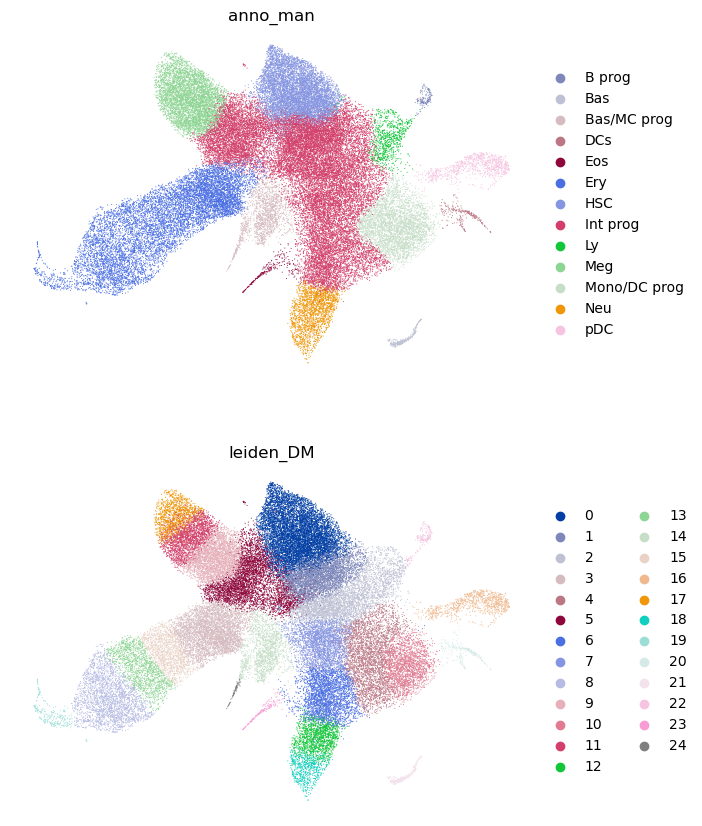

In [8]:
sc.pl.umap(tom_pos, color=['anno_man','leiden_DM'], frameon=False, ncols=1)

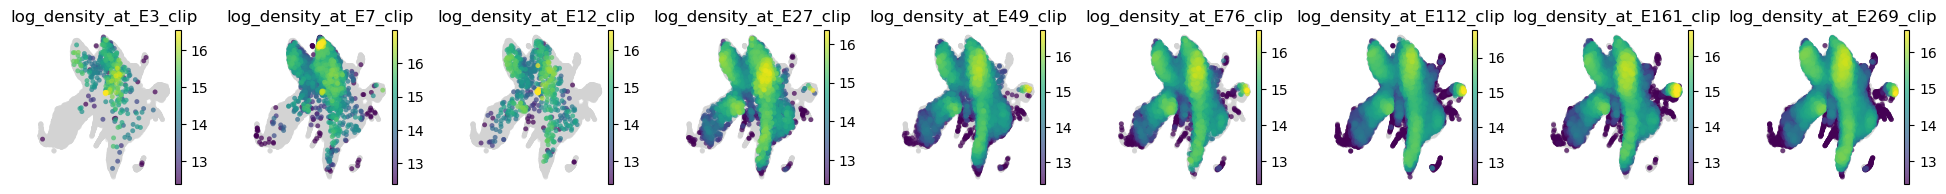

In [29]:
pl.umap_by_time(lambda x : f"log_density_at_E{x}_clip", tom_pos);

In [5]:
train_DS = reader.HigDimRe_AnnDS(AnnData=ery_mk_ad, n_dimension = 5, 
                               cellstate_key="DM_EigenVectors",  #'DM_EigenVector'
)
